# 01 — CNN Training — ResNet-50 (ISIC 2019)

Training **ResNet-50** (CNN baseline) on ISIC 2019 for skin lesion classification (8 classes).

**Reference:** *Zammit & Murugan — "Enhanced Multi-Class Skin Lesion Classification of Dermoscopic Images Using an Ensemble of Deep Learning Models"* (JCTA 2025)

**Paper parameters applied:**
| Parameter | Value |
|-----------|-------|
| Image size | 224×224 |
| Split | 75% train / 25% val + official test |
| Epochs | 150 |
| Optimizer | Adam (lr=1e-4, wd=1e-4) |
| Class balancing | WeightedRandomSampler |
| Augmentation | Rotation, Grid/Optical distortion, Flip, Affine (p≈0.1) |

**Role in thesis:** ResNet-50 = unique CNN baseline (contrôle positif) pour comparer avec les 4 ViTs.

**Environment:** Kaggle (GPU T4 / P100)

## 0. Kaggle Setup — Clone repo & install deps

In [2]:
# Run once — remove old version if exists
!rm -rf /kaggle/working/xai-vit-medical
!git clone https://github.com/youssef-nouiouar/xai-vit-medical.git /kaggle/working/xai-vit-medical

Cloning into '/kaggle/working/xai-vit-medical'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 80 (delta 10), reused 78 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 69.21 KiB | 2.39 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [3]:
!pip install -q timm albumentations loguru
!pip install -q PyDrive2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.7 MB/s eta 0:00:00


In [4]:
# Google Drive authentication (to save checkpoints)
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

## 0b. Download ISIC 2019 Dataset

In [5]:
import os, requests, zipfile

DATA_DIR = '/kaggle/working/xai-vit-medical/data/isic2019'
os.makedirs(DATA_DIR, exist_ok=True)

URLS = {
    'train_zip': 'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_Input.zip',
    'train_csv': 'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv',
    'test_zip':  'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_Input.zip',
    'test_csv':  'https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv',
}

def download(url, dest):
    print(f'Downloading {os.path.basename(dest)} ...')
    r = requests.get(url, stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f'  done ({os.path.getsize(dest)/1e6:.1f} MB)')

def extract_and_remove(zip_path, extract_to):
    print(f'Extracting {os.path.basename(zip_path)} ...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)
    os.remove(zip_path)
    print('  done.')

# Training set
train_zip = f'{DATA_DIR}/ISIC_2019_Training_Input.zip'
download(URLS['train_zip'], train_zip)
extract_and_remove(train_zip, DATA_DIR)
download(URLS['train_csv'], f'{DATA_DIR}/ISIC_2019_Training_GroundTruth.csv')

# Test set
test_zip = f'{DATA_DIR}/ISIC_2019_Test_Input.zip'
download(URLS['test_zip'], test_zip)
extract_and_remove(test_zip, DATA_DIR)
download(URLS['test_csv'], f'{DATA_DIR}/ISIC_2019_Test_GroundTruth.csv')

print('\nDataset ready.')

  done (9771.6 MB)
Extracting ISIC_2019_Training_Input.zip ...
  done.
  done (1.3 MB)
  done (3823.2 MB)
Extracting ISIC_2019_Test_Input.zip ...
  done.
  done (0.5 MB)

Dataset ready.


## 1. Setup & Dependencies

In [6]:
import os, sys, json, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import classification_report, confusion_matrix

# Project root
PROJECT_ROOT = '/kaggle/working/xai-vit-medical'
sys.path.insert(0, PROJECT_ROOT)

from src.data.isic_dataset import ISICDataset
from src.utils.seed import set_seed

# Reproducibility
SEED = 42
set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU   : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('Dependencies loaded.')

Device : cuda
  GPU   : Tesla T4
  VRAM  : 15.6 GB
Dependencies loaded.


## 2. Configuration

Paramètres du papier (Zammit & Murugan 2025) :

In [7]:
# ---- Paths ----
DATA_DIR  = '/kaggle/working/xai-vit-medical/data/isic2019'
SAVE_DIR  = '/kaggle/working/xai-vit-medical/outputs/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ---- Dataset (paper: 75/25 split + official test) ----
IMAGE_SIZE  = 224
NUM_CLASSES = 8
VAL_RATIO   = 0.25      # paper: 25% val
NUM_WORKERS = 2

# ---- Training (paper) ----
BATCH_SIZE   = 32
EPOCHS       = 150
LR           = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 15

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
CLASS_NAMES_FULL = {
    'MEL':'Melanoma', 'NV':'Naevus mélanocytaire',
    'BCC':'Carcinome basocellulaire', 'AK':'Kératose actinique',
    'BKL':'Kératose bénigne', 'DF':'Dermatofibrome',
    'VASC':'Lésion vasculaire', 'SCC':'Carcinome épidermoïde'
}

print('Configuration:')
for k, v in [('Image size', f'{IMAGE_SIZE}×{IMAGE_SIZE}'), ('Batch size', BATCH_SIZE),
             ('Epochs', EPOCHS), ('LR', LR), ('Val ratio', VAL_RATIO),
             ('Num classes', NUM_CLASSES), ('Save dir', SAVE_DIR)]:
    print(f'  {k:12s}: {v}')

Configuration:
  Image size  : 224×224
  Batch size  : 32
  Epochs      : 150
  LR          : 0.0001
  Val ratio   : 0.25
  Num classes : 8
  Save dir    : /kaggle/working/xai-vit-medical/outputs/models


## 3. Dataset & DataLoaders

**Augmentations du papier (Table 1) :**

| Augmentation | Probabilité |
|---|---|
| Center Crop | — |
| Random Rotation 90° | 0.1 |
| Grid Distortion | 0.1 |
| Horizontal Flip | 0.1 |
| Vertical Flip | 0.1 |
| Optical Distortion | 0.1 |
| Affine Transformation | 0.1 |

**Équilibrage des classes :** WeightedRandomSampler (Section 3.3 du papier)

In [10]:
def get_train_transform(image_size: int = 224) -> A.Compose:
    """Augmentations du papier (Table 1)."""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.CenterCrop(image_size, image_size, p=0.3),
        A.RandomRotate90(p=0.1),
        A.GridDistortion(distort_limit=0.3, p=0.1),
        A.HorizontalFlip(p=0.1),
        A.VerticalFlip(p=0.1),
        A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=0.1),
        A.Affine(scale=(0.9, 1.1), translate_percent=(-0.1, 0.1),
                 rotate=(-30, 30), shear=(-10, 10), p=0.1),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

def get_val_transform(image_size: int = 224) -> A.Compose:
    """Val/Test : resize + normalize uniquement."""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

# ---- Datasets ----
# use_official_test=True  → train/val from ISIC_2019_Training_Input
#                           test  from ISIC_2019_Test_Input
train_dataset = ISICDataset(
    root_dir=DATA_DIR, split='train',
    image_size=IMAGE_SIZE, use_albumentations=False,
    use_official_test=True, val_ratio=VAL_RATIO,
)
train_dataset.use_albumentations = True
train_dataset.transform = get_train_transform(IMAGE_SIZE)

val_dataset = ISICDataset(
    root_dir=DATA_DIR, split='val',
    image_size=IMAGE_SIZE, use_albumentations=False,
    use_official_test=True, val_ratio=VAL_RATIO,
)
val_dataset.use_albumentations = True
val_dataset.transform = get_val_transform(IMAGE_SIZE)

test_dataset = ISICDataset(
    root_dir=DATA_DIR, split='test',
    image_size=IMAGE_SIZE, use_albumentations=False,
    use_official_test=True, val_ratio=VAL_RATIO,
)
test_dataset.use_albumentations = True
test_dataset.transform = get_val_transform(IMAGE_SIZE)

# ---- Distribution + WeightedRandomSampler ----
class_counts = Counter(train_dataset.labels)
total = len(train_dataset)
print(f'Train : {total} images')
print(f'Val   : {len(val_dataset)} images')
print(f'Test  : {len(test_dataset)} images')
print('\nDistribution (train):')
for i, name in enumerate(CLASS_NAMES):
    cnt = class_counts.get(i, 0)
    print(f'  {name:5s}: {cnt:>5d}  ({cnt/total*100:.1f}%)')

class_weights = torch.tensor(
    [total / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
)
sample_weights = class_weights[train_dataset.labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_dataset), replacement=True)

# ---- DataLoaders ----
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')
print(f'Class weights : {class_weights.numpy().round(2)}')

Train : 18998 images
Val   : 6333 images
Test  : 8238 images

Distribution (train):
  MEL  :  3392  (17.9%)
  NV   :  9656  (50.8%)
  BCC  :  2492  (13.1%)
  AK   :   650  (3.4%)
  BKL  :  1968  (10.4%)
  DF   :   179  (0.9%)
  VASC :   190  (1.0%)
  SCC  :   471  (2.5%)

Train batches : 593
Val   batches : 99
Test  batches : 129
Class weights : [ 0.7   0.25  0.95  3.65  1.21 13.27 12.5   5.04]


## 4. Model — ResNet-50

- Pré-entraîné ImageNet (transfer learning)
- Toutes les couches dé-gelées pour le fine-tuning
- Tête de classification : FC → 8 classes

In [9]:
def build_resnet50(num_classes: int = NUM_CLASSES, pretrained: bool = True) -> nn.Module:
    """ResNet-50 depuis timm, tête remplacée pour num_classes."""
    model = timm.create_model('resnet50', pretrained=pretrained, num_classes=num_classes)
    total  = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'ResNet-50  (pretrained={pretrained})')
    print(f'  Classifier : {model.get_classifier()}')
    print(f'  Params total     : {total:,}')
    print(f'  Params trainable : {trainable:,}')
    return model

# Architecture check
_m = build_resnet50()
_x = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
assert _m(_x).shape == (1, NUM_CLASSES), 'Shape mismatch'
del _m, _x
torch.cuda.empty_cache()
print('Architecture OK.')

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet-50  (pretrained=True)
  Classifier : Linear(in_features=2048, out_features=8, bias=True)
  Params total     : 23,524,424
  Params trainable : 23,524,424
Architecture OK.


## 5. Training Loop

| Composant | Choix | Référence papier |
|-----------|-------|------------------|
| Loss | CrossEntropyLoss | Standard multi-classe |
| Optimizer | Adam (lr=1e-4, wd=1e-4) | Section 3.4 |
| Scheduler | ReduceLROnPlateau (patience=5, factor=0.5) | Stabilité |
| Mixed Precision | torch.amp (FP16) | Vitesse + mémoire |
| Early stopping | patience=15 sur val_loss | Anti-overfitting |
| Epochs | 150 | Section 4 |

In [13]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scaler: torch.cuda.amp.GradScaler,
    device: torch.device,
) -> tuple[float, float]:
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc='  Train', leave=False)
    for images, labels, _ in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float, np.ndarray, np.ndarray]:
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels, _ in tqdm(loader, desc='  Eval ', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(
    model: nn.Module,
    model_name: str,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = EPOCHS,
    lr: float = LR,
    weight_decay: float = WEIGHT_DECAY,
    patience: int = PATIENCE,
    device: torch.device = DEVICE,
) -> tuple[nn.Module, dict]:
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    save_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')

    print(f'\n{"="*60}')
    print(f'Training {model_name}  |  {epochs} epochs  |  lr={lr}  |  patience={patience}')
    print(f'{"="*60}\n')

    for epoch in range(1, epochs + 1):
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch}/{epochs}  (lr={current_lr:.2e})')

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'history': history,
                'class_names': CLASS_NAMES,
                'model_name': model_name,
            }, save_path)
            tag = ' ★'
        else:
            epochs_no_improve += 1

        print(f'  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}')
        print(f'  val_loss  ={val_loss:.4f}  val_acc  ={val_acc:.4f}{tag}')

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)')
            break

    print(f'\nBest val_loss={best_val_loss:.4f} — checkpoint: {save_path}')
    return model, history

print('Training functions defined.')

Training functions defined.


## 6. Train ResNet-50

In [14]:
resnet50 = build_resnet50(num_classes=NUM_CLASSES, pretrained=True)

resnet50, resnet50_history = train_model(
    model=resnet50,
    model_name='resnet50',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=DEVICE,
)

ResNet-50  (pretrained=True)
  Classifier : Linear(in_features=2048, out_features=8, bias=True)
  Params total     : 23,524,424
  Params trainable : 23,524,424

Training resnet50  |  150 epochs  |  lr=0.0001  |  patience=15

Epoch 1/150  (lr=1.00e-04)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Eval :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=1.6290  train_acc=0.4292
  val_loss  =1.1210  val_acc  =0.6097 ★
Epoch 2/150  (lr=1.00e-04)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=0.0359  train_acc=0.9892
  val_loss  =0.6199  val_acc  =0.8558
Epoch 44/150  (lr=6.25e-06)


  Train:   0%|          | 0/593 [00:00<?, ?it/s]

  Eval :   0%|          | 0/99 [00:00<?, ?it/s]

  train_loss=0.0274  train_acc=0.9909
  val_loss  =0.6359  val_acc  =0.8550

Early stopping at epoch 44 (no improvement for 15 epochs)

Best val_loss=0.6072 — checkpoint: /kaggle/working/xai-vit-medical/outputs/models/resnet50_best.pth


## 7. Evaluation & Results

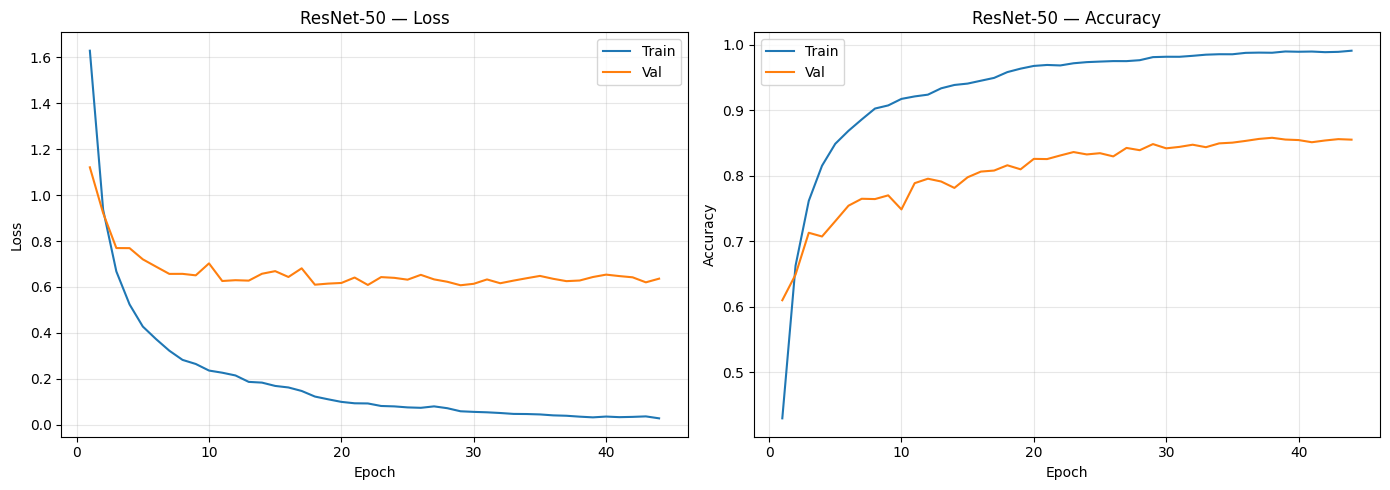

Saved: /kaggle/working/xai-vit-medical/outputs/models/ResNet-50_curves.png


In [15]:
def plot_training_curves(history: dict, model_name: str) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs_range, history['train_loss'], label='Train')
    ax1.plot(epochs_range, history['val_loss'],   label='Val')
    ax1.set(xlabel='Epoch', ylabel='Loss', title=f'{model_name} — Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs_range, history['train_acc'], label='Train')
    ax2.plot(epochs_range, history['val_acc'],   label='Val')
    ax2.set(xlabel='Epoch', ylabel='Accuracy', title=f'{model_name} — Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(SAVE_DIR, f'{model_name}_curves.png')
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')


def evaluate_full(
    model: nn.Module,
    loader: DataLoader,
    model_name: str,
    split: str = 'val',
    device: torch.device = DEVICE,
) -> dict:
    loss, acc, preds, labels = evaluate(model, loader, nn.CrossEntropyLoss(), device)
    print(f'\n{model_name} — {split.upper()} SET')
    print(f'  Loss     : {loss:.4f}')
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'\n{classification_report(labels, preds, target_names=CLASS_NAMES, digits=4)}')

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set(xlabel='Predicted', ylabel='True',
           title=f'{model_name} — Confusion Matrix ({split})')
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, f'{model_name}_cm_{split}.png')
    plt.savefig(out, dpi=150)
    plt.show()
    return {'loss': loss, 'acc': acc, 'preds': preds, 'labels': labels}


# ---- Courbes d'entraînement ----
plot_training_curves(resnet50_history, 'ResNet-50')

Best checkpoint: epoch 29  val_loss=0.6072  val_acc=0.8483


  Eval :   0%|          | 0/99 [00:00<?, ?it/s]


ResNet-50 — VAL SET
  Loss     : 0.6072
  Accuracy : 0.8483  (84.83%)

              precision    recall  f1-score   support

         MEL     0.7655    0.7655    0.7655      1130
          NV     0.9064    0.9080    0.9072      3219
         BCC     0.8341    0.9073    0.8692       831
          AK     0.7604    0.6728    0.7139       217
         BKL     0.7662    0.7393    0.7525       656
          DF     0.7797    0.7667    0.7731        60
        VASC     0.8485    0.8889    0.8682        63
         SCC     0.7823    0.6178    0.6904       157

    accuracy                         0.8483      6333
   macro avg     0.8054    0.7833    0.7925      6333
weighted avg     0.8474    0.8483    0.8472      6333



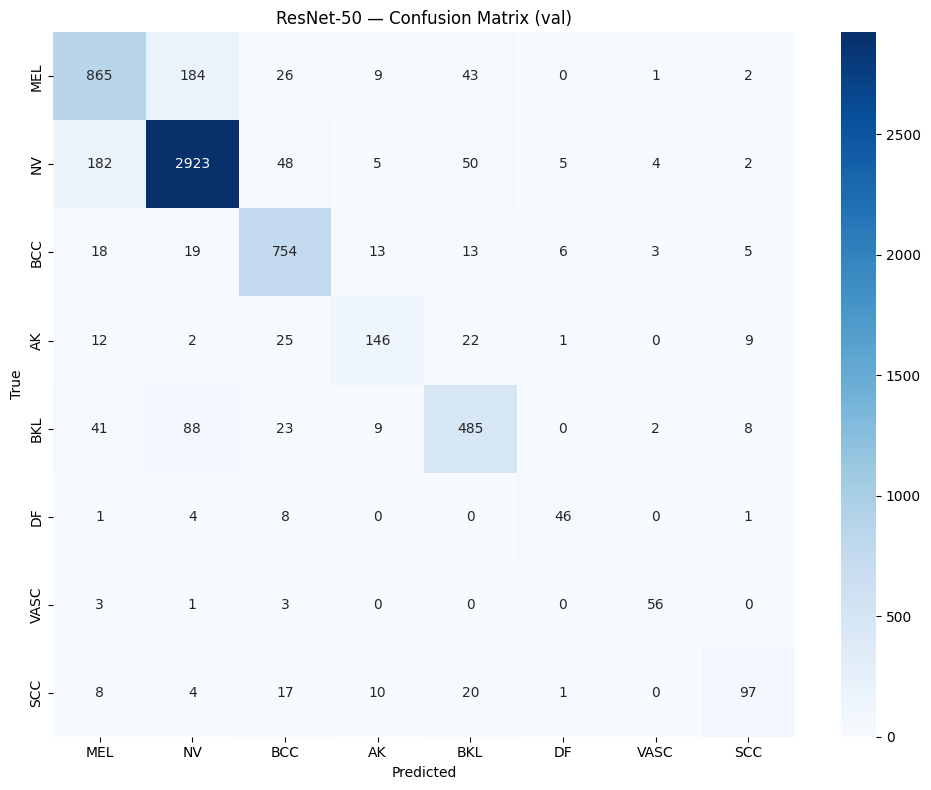

In [16]:
# ---- Évaluation sur val set ----
# Charger le meilleur checkpoint
ckpt = torch.load(os.path.join(SAVE_DIR, 'resnet50_best.pth'), map_location=DEVICE)
resnet50.load_state_dict(ckpt['model_state_dict'])
print(f"Best checkpoint: epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}  val_acc={ckpt['val_acc']:.4f}")

resnet50_val_results = evaluate_full(resnet50, val_loader, 'ResNet-50', split='val')

  Eval :   0%|          | 0/129 [00:00<?, ?it/s]


ResNet-50 — TEST SET
  Loss     : 2.7004
  Accuracy : 0.5339  (53.39%)

              precision    recall  f1-score   support

         MEL     0.7029    0.3281    0.4474      3374
          NV     0.7028    0.8257    0.7593      2495
         BCC     0.3547    0.7621    0.4840       975
          AK     0.1800    0.2166    0.1966       374
         BKL     0.3748    0.4197    0.3960       660
          DF     0.2985    0.4396    0.3556        91
        VASC     0.3052    0.4519    0.3643       104
         SCC     0.2687    0.2606    0.2646       165

    accuracy                         0.5339      8238
   macro avg     0.3985    0.4630    0.4085      8238
weighted avg     0.5934    0.5339    0.5250      8238



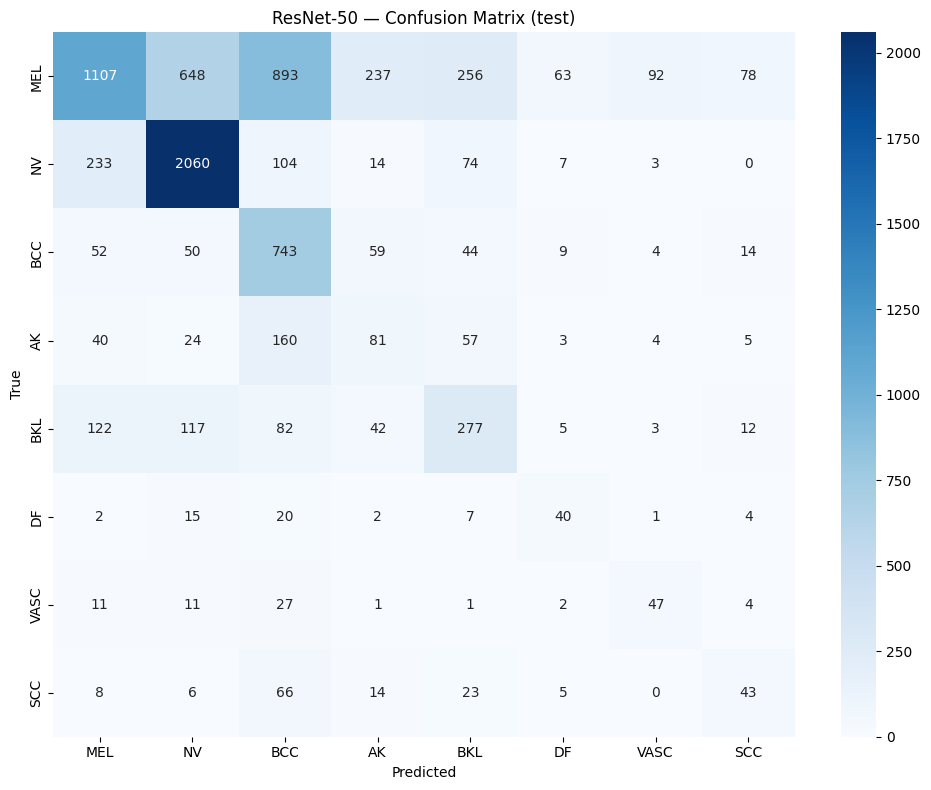

In [17]:
# ---- Évaluation sur test set officiel ----
resnet50_test_results = evaluate_full(resnet50, test_loader, 'ResNet-50', split='test')

## 8. Save Summary & Upload to Google Drive

In [18]:
summary = {
    'resnet50': {
        'val_loss': float(resnet50_val_results['loss']),
        'val_acc':  float(resnet50_val_results['acc']),
        'test_loss': float(resnet50_test_results['loss']),
        'test_acc':  float(resnet50_test_results['acc']),
        'best_epoch': int(ckpt['epoch']),
        'epochs_trained': len(resnet50_history['train_loss']),
    }
}

summary_path = os.path.join(SAVE_DIR, 'cnn_training_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print('CNN Training Summary:')
print(f'  val_acc  = {summary["resnet50"]["val_acc"]:.4f}')
print(f'  test_acc = {summary["resnet50"]["test_acc"]:.4f}')
print(f'  best epoch = {summary["resnet50"]["best_epoch"]}')

CNN Training Summary:
  val_acc  = 0.8483
  test_acc = 0.5339
  best epoch = 29


In [23]:
# Upload checkpoint + summary to a specific Drive folder
SAVE_DIR  = '/kaggle/working/xai-vit-medical/outputs/models'
folder_id = "1eq-Jt6O6gO0Ck_oQYwmmc2qrCVLfKlec"   # <--- put your folder ID

files_to_upload = [
    'resnet50_best.pth',
    'cnn_training_summary.json',
    'ResNet-50_curves.png',
    'ResNet-50_cm_val.png',
    'ResNet-50_cm_test.png'
]

for fname in files_to_upload:
    fpath = os.path.join(SAVE_DIR, fname)

    if os.path.exists(fpath):
        drive_file = drive.CreateFile({
            'title': fname,
            'parents': [{'id': folder_id}]
        })

        drive_file.SetContentFile(fpath)
        drive_file.Upload()

        print(f"Uploaded: {fname}  (id={drive_file['id']})")
    else:
        print(f"Not found (skipped): {fname}")

print("\nDone. Files uploaded to folder.")


Uploaded: resnet50_best.pth  (id=1zPmo_aRxZlmicDOTpQWb5eL7sLq2HQK-)
Uploaded: cnn_training_summary.json  (id=16mMJ1ZnPariEydLlZWrgVABrtRH-GKCP)
Uploaded: ResNet-50_curves.png  (id=1NotZA2jlBhTQXLxkYz1f2TxASTefHVqr)
Uploaded: ResNet-50_cm_val.png  (id=1up100p-isXqIrpOV9d85CWvdR5ts4ofU)
Not found (skipped): ResNet-50_cm.png

Done. Files uploaded to folder.
